## ======================================================================
## 📊 Hopify LTV Actual vs LTV Goal per Segment (Side-By-Side)
## ======================================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties

## ================================
## 📁 Set Base Path to Project Root
## ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ================================
## 📥 Load & Clean Data
## ================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "14_hopify_ltv_seg_v_target.csv"
)

df = pd.read_csv(file_path)

# Clean and standardize
df.columns = df.columns.str.lower().str.strip()
df.rename(columns={"customer_segment": "segment"}, inplace=True)
df["segment"] = df["segment"].str.title().str.strip()

# Reshape for grouped bar plot
df_melted = df.melt(
    id_vars="segment",
    value_vars=["estimated_ltv", "ltv_target"],
    var_name="metric",
    value_name="ltv_value"
)

# ================================
# 🎨 Plotting
# ================================

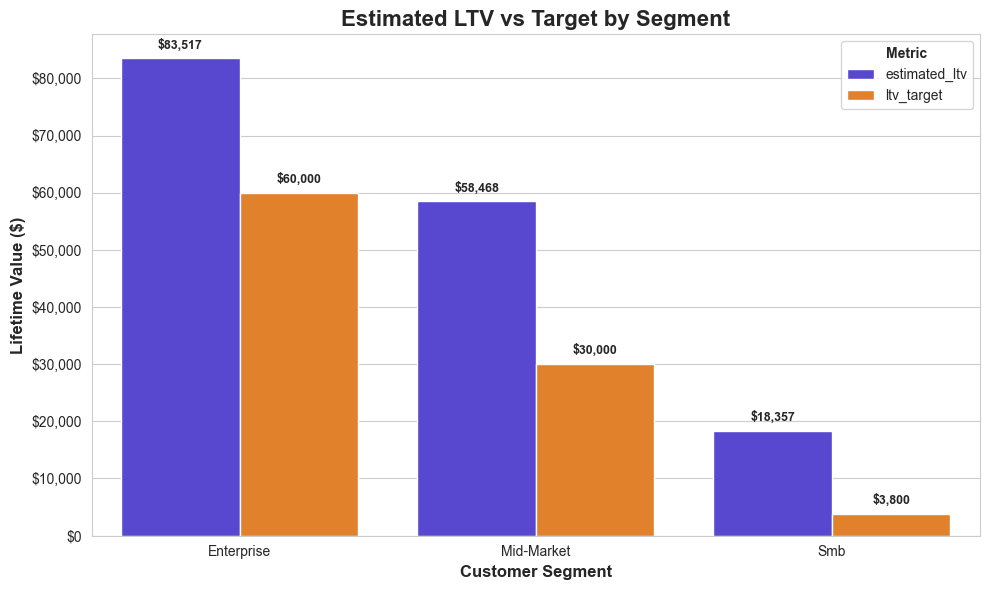

In [3]:
sns.set_style("whitegrid")
palette = {
    "estimated_ltv": "#4631e5",
    "ltv_target": "#ff7f0e"
}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_melted,
    x="segment",
    y="ltv_value",
    hue="metric",
    palette=palette
)

# Add value labels
for bar in ax.patches:
    height = bar.get_height()
    if pd.notna(height) and height > 0:
        ax.annotate(
            f"${height:,.0f}",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points"
        )

# Final formatting
bold_font = FontProperties(weight="bold")
ax.set_title("Estimated LTV vs Target by Segment", fontsize=16, fontweight="bold")
ax.set_xlabel("Customer Segment", fontsize=12, fontweight="bold")
ax.set_ylabel("Lifetime Value ($)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.tick_params(axis='x', labelrotation=0)

plt.legend(
    title="Metric",
    title_fontproperties=bold_font,
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()


# ================================
# 💾 Save & Display Plot
# ================================

In [4]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "02_project_revenue_profit_analysis",
    "hopify_ltv_vs_target_by_segment.png"
)
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Plot saved to: {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Plot saved to: /Users/jade.herman/Documents/00_github/hopify_saas_kpi_analysis/05_visuals/02_project_revenue_profit_analysis/hopify_ltv_vs_target_by_segment.png
